In [1]:

import numpy as np
from generate_price_data import *
import matplotlib.pyplot as plt
import pandas as pd
from constructing_models import *

C:\Users\tobia\AppData\Roaming\Python\Python311\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\tobia\AppData\Roaming\Python\Python311\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\tobia\AppData\Roaming\Python\Python311\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please 

Construct action space and plot the distribution of portfolio weights for each action

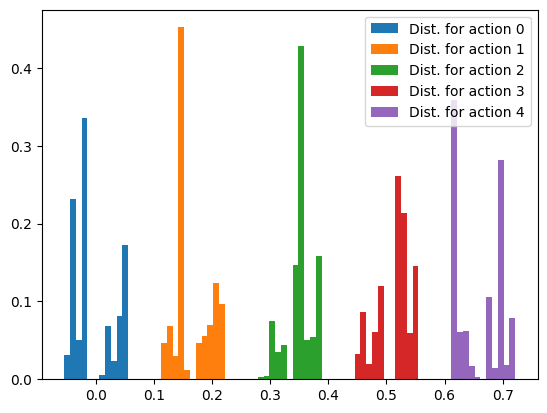

In [2]:
a = 5 # size of action space
n = 10 # num asssets

# shape (n, a)
# we want rowsums to equal 1, therefor a dirichlet distribution is optimal here
A = np.random.dirichlet(np.full(n, 1), a)
# rowsums are 1
fig, ax = plt.subplots() # x axis is actions (a)

width = 1 / (2 * a * n) - 0.01
gap = 0.01
offsets = (np.arange(a) - (a - 1) / 2) * width

n_even = n % 2 == 0

for i in range(a):

    c = i / (a + 1)

    xvalues1 = [c - i*gap for i in range(1, n // 2 + 1)]
    xvalues2 = [c + i*gap for i in range(1, n // 2 + 1)]
    if not n_even:
        ax.bar(xvalues1 + [c] + xvalues2, A[i, :], width=gap, label=f"Dist. for action {i}")
    else:
        ax.bar(xvalues1 + xvalues2, A[i, :], width=gap, label=f"Dist. for action {i}")

plt.legend()
plt.show()




Construct regime transition matrix and generate the regime sequence

In [3]:
m = 3 # num regimes
M = np.array([
    [0.95, 0.05, 0.00],
    [0.06, 0.91, 0.03],
    [0.00, 0.12, 0.88]
])

init_regime_prob_dist = [0.7, 0.15, 0.15]

T = 1000
T_test = 200

# construct regime sequence
# regime sequence is purely needed for synthetic data creation,
# as we need different parameters for the Heston model per regime
regime = np.random.choice(range(m), p=init_regime_prob_dist)
true_regimes_total = np.empty(T + T_test, dtype=int)
true_regimes_total[0] = regime
for t in range(1, T + T_test):
    next_regime = np.random.choice(range(m), p=M[regime, :])
    true_regimes_total[t] = next_regime
    regime = next_regime

Generate synthetic data

75
color green: low vol
color yellow: medium vol
color red: high vol


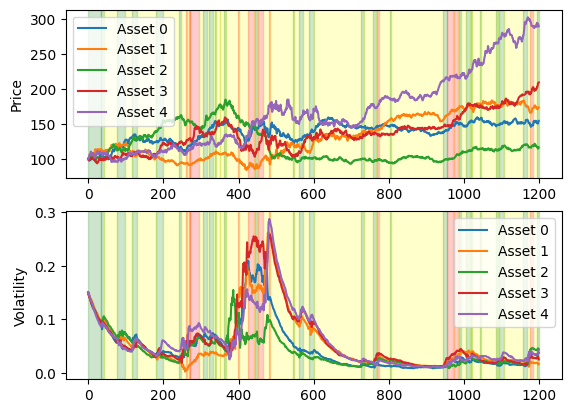

In [4]:
price_data_total = np.empty((T + T_test, n))
volatility_data_total = np.empty((T + T_test, n))

# each column corresponds with values for a certain regime
xi_values = [0.05, 0.2, 0.6] # volatility of volatility
kappa_values = [6, 1.0, 0.5] # mean reversion rate
theta_values = [0.01, 0.2, 1.2] # mean volatility
mu_values = [0.0, 1.0, -1.0] # price drift

# initial volatility and price for assets
V0 = np.full(n, 0.15)
S0 = np.full(n, 100)

price_data_total = np.empty((T + T_test, n))
volatility_data_total = np.empty((T + T_test, n))

fig, (ax1, ax2) = plt.subplots(2)

x_breakpoints = []
x_breakpoints_labels = []

t = 0
while t < T + T_test:
    this_regime = true_regimes_total[t]
    tt = t + 1
    while tt < T + T_test:
        if true_regimes_total[tt] == this_regime:
            tt += 1
        else:
            break
    x_breakpoints.append(tt)
    x_breakpoints_labels.append(this_regime)
    volatility_data_total[t:tt, :] = np.array([
            generate_volatility(
                V0=V0[i],
                xi=xi_values[this_regime],
                theta=theta_values[this_regime],
                kappa=kappa_values[this_regime],
                N=tt - t,
                dt=1/365
            )
            for i in range(n)
        ]).T
    price_data_total[t:tt, :] = np.array([
        generate_prices(
            vola_values=volatility_data_total[t:tt, i],
            S0=S0[i],
            N=tt - t,
            mu=mu_values[this_regime],
            dt=1/365
    )
        for i in range(n)
    ]).T
    V0 = volatility_data_total[tt - 1, :]
    S0 = price_data_total[tt - 1, :]
    t = tt

x_breakpoints_labels.append(this_regime)
x_breakpoints.append(t)

price_data = price_data_total[:T]
price_data_eval = price_data_total[T:]
volatility_data = volatility_data_total[:T]
volatility_data_data_eval = volatility_data_total[T:]

for i in range(a):
    ax1.plot(range(T + T_test), price_data_total[:, i], label=f"Asset {i}")
    ax2.plot(range(T + T_test), volatility_data_total[:, i], label=f"Asset {i}")

ax1.legend()
ax2.legend()
ax1.set_ylabel("Price")
ax2.set_ylabel("Volatility")

colors = ["green", "yellow", "red"]
color_labels = ["low vol", "medium vol", "high vol"]

for i in range(len(x_breakpoints) - 1):
    ax1.axvspan(x_breakpoints[i],
                x_breakpoints[i + 1], color=colors[x_breakpoints_labels[i]],
                alpha=0.2)
    ax2.axvspan(x_breakpoints[i],
                x_breakpoints[i + 1], color=colors[x_breakpoints_labels[i]],
                alpha=0.2)

true_regimes = true_regimes_total[:T]
true_regimes_eval = true_regimes_total[T:]

ax1.axvspan(0, x_breakpoints[0], color=colors[true_regimes[0]], alpha=0.2)
ax2.axvspan(0, x_breakpoints[0], color=colors[true_regimes[0]], alpha=0.2)

print(len(x_breakpoints_labels))

for c, cl in zip(colors, color_labels):
    print(f"color {c}: {cl}")

plt.show()

### General procedure

For every timestep in the data:

-Feed $p\times v$ matrix, where $p$ is the lookback period and $v$ the feature dimension, to the model to obtain Q-values and use these values to determine next action to take.

-Determine the next state to be in when taking this action, and compute the reward.

-Store the information (reward, state, action taken) into the replay buffer.

-When past a certain threshold $t_{\text{current}}>t_{\text{threshold}}$, sample a random set from the replay buffer and use this for the model to learn, with the target Q-values being computed using the Bellman equation. Update the weights in the model for it to learn.

In the context of this implementation, we need to do the following specific steps for the updating of the model's weights.

-Sample (state, reward, action, next\_state, done) for every batch inside of the sample and action.

-Compute $Q_{\text{current}}$ and $Q_{\text{next}}$ using the current and next states. Let the $Q_{\text{target}}$ be the current Q-values.

-We then use the Bellman equation to compute the optimal Q-values for each best action corresponding with each entry in the sample from the memory buffer.

In [5]:
total_returns = pd.DataFrame(price_data_total).pct_change(axis=0).to_numpy()
returns_train = total_returns[:T].copy()
returns_train[0, :] = np.zeros(n)

print(returns_train)
print()
print(returns_train.shape)

[[ 0.          0.          0.         ...  0.          0.
   0.        ]
 [-0.01069451  0.00026416  0.01643099 ...  0.00766588  0.01191269
   0.00260257]
 [-0.0105282   0.00524613 -0.00146008 ... -0.02430799 -0.0432878
   0.03298664]
 ...
 [-0.00106414  0.00295631 -0.01582635 ...  0.01036861 -0.00593551
  -0.00419658]
 [-0.00651694 -0.00695011  0.01159441 ... -0.00477255  0.00365501
  -0.01287021]
 [-0.00587116 -0.01359133 -0.00907607 ... -0.01078455 -0.00029015
   0.00268965]]

(1000, 10)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 686ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1

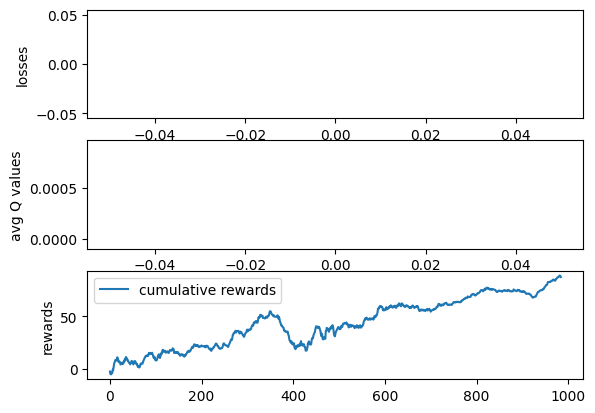

In [6]:
# construct returns and volatility data 
vola_lookback = 15
mean_returns = np.mean(returns_train, axis=1)
vola = pd.Series(mean_returns).rolling(vola_lookback, min_periods=1).std().values.copy()
vola[0] = 0
rb_capacity = 1000
rb_sample_size = 5
gamma = 0.95
t_replay_buffer = 30
training_lookback_period = 15
epsilon_decay = 0.99

# define DQN model
dqn = Model1(
    state_space=returns_train,
    rb_sample_size=rb_sample_size,
    gamma=gamma,
    rep_buffer_size=rb_capacity,
    action_space=A,
    training_lookback_period=training_lookback_period,
    t_replay_buffer=t_replay_buffer,
    epsilon_decay=epsilon_decay
)

# train model and plot some statistics
losses, avg_q_values, rewards = dqn.train()
cum_rewards = np.cumsum(rewards)
fig, (ax1, ax2, ax3) = plt.subplots(3)

ax1.plot(losses)
ax1.set_ylabel('losses')
ax2.plot(avg_q_values, label="avg Q-values")
ax2.set_ylabel('avg Q values')
ax3.plot(cum_rewards, label="cumulative rewards")
ax3.set_ylabel('rewards')
ax3.legend()
plt.show()





Compute returns for equal weights, to compare against model weights

In [7]:
eq_weights_return = returns_train @ np.full(n, 1/n)
eq_weights_return_cumprod = np.cumprod(1 + eq_weights_return) - 1

# save DQN
dqn.save(dirname=Path.cwd() / "producedModels" / "simpleModels", modelname="simpleModel")

In [8]:
returns_test = total_returns[T:]


deployer = ModelDeployer(
    modelpath=Path.cwd() / "producedModels" / "simpleModels" / "simpleModel.keras",
    data=returns_test,
    action_space=A
)

result = deployer.run()
print('len result:', len(result))

df, cumreturns_eqw, cum_return, returns_vola_ann, returns_vola_ann_eqw = deployer.run()
df


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━

,mean_returns,sharpe,sortino,mean_ann_volatility
equal_weights,0.009569,3.492219,6.286990,0.002726
dqn_weights,0.007047,1.692733,2.931955,0.004641


Note that the above statistics are not at all realistic, because we have used synthetic data using custom tunable parameters.

In [9]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
fig = make_subplots(rows=1, cols=2)
fig.add_trace(go.Scatter(x=list(range(len(cumreturns_eqw))), y=cumreturns_eqw, name="cumulative_returns_equal_weights"), row=1, col=1)
fig.add_trace(go.Scatter(x=list(range(len(cum_return))), y=cum_return, name="cumulative_returns_dqn"), row=1, col=1)
fig.add_trace(go.Scatter(x=list(range(len(returns_vola_ann_eqw))), y=returns_vola_ann_eqw, name="ann_volatility_equal_weights"), row=1, col=2)
fig.add_trace(go.Scatter(x=list(range(len(returns_vola_ann_eqw))), y=returns_vola_ann, name="ann_volatility_dqn"), row=1, col=2)
fig.show()